In [1]:
# # %pip install --upgrade pip
# %pip install gmsh
# %pip install meshio --user

In [ ]:
import gmsh
import numpy as np
import scipy.optimize
import scipy.linalg
import matplotlib.pyplot as plt
import matplotlib


In [3]:
show_gmsh_window = False
msh_file_name = "shell_mesh_opt.msh"

In [4]:
gmsh.initialize()

dx = 0.2
# Annulus inner and outer radius
a = .25
b = 1.5

points = [
  # Bounding box vertices
  gmsh.model.geo.addPoint(-0.5, -0.5, 0, dx),
  gmsh.model.geo.addPoint(0.5,  -0.5, 0, dx),
  gmsh.model.geo.addPoint(0.5,  0.5,  0, dx),
  gmsh.model.geo.addPoint(-0.5, 0.5,  0, dx),
  # Inner circle points
  gmsh.model.geo.addPoint(0.0, 0, 0, dx),
  gmsh.model.geo.addPoint(a, 0, 0, dx),
  gmsh.model.geo.addPoint(-a, 0, 0, dx),
  # Outer circle points
  gmsh.model.geo.addPoint(0.0, 0.0, 0, dx),
  gmsh.model.geo.addPoint(b, 0.0, 0, dx),
  gmsh.model.geo.addPoint(-b, 0.0, 0, dx),
]
lines = [
  # Box lines
  # gmsh.model.geo.add_line(points[0], points[1]),
  # gmsh.model.geo.add_line(points[1], points[2]),
  # gmsh.model.geo.add_line(points[2], points[3]),
  # gmsh.model.geo.add_line(points[3], points[0]),
]

arcs = [
  # Inner circle
  gmsh.model.geo.addCircleArc(points[5], points[4], points[6]),
  gmsh.model.geo.addCircleArc(points[6], points[4], points[5]),
  # Outer circle
  gmsh.model.geo.addCircleArc(points[8], points[7], points[9]),
  gmsh.model.geo.addCircleArc(points[9], points[7], points[8]),
]

loops = [
  # Bounding box loop
  # gmsh.model.geo.add_curve_loop(lines),
  # Inner circle loop
  gmsh.model.geo.add_curve_loop(arcs[0:2]),
  # Outer circle loop
  gmsh.model.geo.add_curve_loop(arcs[2:4]),
]

surfaces = [
  # Bounding box and inner circle
  # gmsh.model.geo.add_plane_surface([loops[0], loops[1]]),
  # Outer circle and inner circle
  gmsh.model.geo.add_plane_surface([loops[1], loops[0]]),
]

# Physical groups
surfaces_physical = [gmsh.model.addPhysicalGroup(2, surfaces, name="surface")]
# lines_physical = [gmsh.model.addPhysicalGroup(1, lines, name=f"box")]
inner_arcs_physical = [gmsh.model.addPhysicalGroup(1, arcs[0:2], name=f"circle_in")]
outer_arcs_physical = [gmsh.model.addPhysicalGroup(1, arcs[2:4], name=f"circle_out")]

gmsh.model.geo.synchronize()
gmsh.model.mesh.generate()
gmsh.write(msh_file_name)

if show_gmsh_window:
  import sys
  if 'close' not in sys.argv:
      gmsh.fltk.run()

gmsh.finalize()

In [5]:
''' Read mesh and process '''
import meshio
# mesh = meshio.read("test_mesh.msh")
mesh = meshio.read(msh_file_name)
mesh

<meshio mesh object>
  Number of points: 259
  Number of cells:
    line: 4
    line: 4
    line: 24
    line: 24
    triangle: 462
  Cell sets: circle_in, circle_out, surface, gmsh:bounding_entities
  Point data: gmsh:dim_tags
  Cell data: gmsh:physical, gmsh:geometrical
  Field data: circle_in, circle_out, surface

In [6]:
n_nodes = mesh.points.shape[0]
n_cells = np.concatenate(mesh.cell_sets["surface"]).size
n_nodes, n_cells

(259, 462)

In [7]:
def read_points(mesh, tag:str, reverse=False):
  # Read list of arrays containing edges [node_idx_i, node_idx_j] for lines or
  # cell (hyperedge) [node_idx_i, node_idx_j, node_idx_k] for tris
  edges = [mesh.cells[i].data[idx_set] for i, idx_set in enumerate(mesh.cell_sets[tag])]
  # Flatten collection of edges into array with shape (ne, 2) belonging to boundary
  edges_flat = np.concatenate([part for part in edges if part.size > 0])
  if reverse:
    edges_flat = np.flip(edges_flat, axis=1)
  # Compute list of coordinates belonging to each edge (n_edges, 2 (vertices on edge), 3 (dimension))
  points = mesh.points[edges_flat]

  # Plot the identified points and print shape
  plt.scatter(points[...,0].ravel(), points[...,1].ravel())
  print(f"Points array shape: {points.shape}")
  return points, edges_flat

Points array shape: (462, 3, 3)


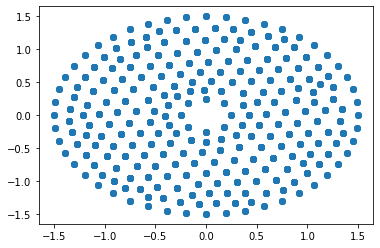

In [8]:
tri_points, tri_indices = read_points(mesh, "surface", reverse=False)

Points array shape: (8, 2, 3)
Points array shape: (48, 2, 3)


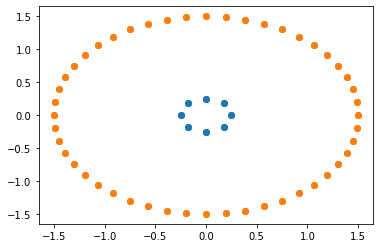

In [9]:
circ_in_points, circ_in_indices = read_points(mesh, "circle_in", reverse=False)
circ_out_points, circ_out_indices = read_points(mesh, "circle_out", reverse=True)

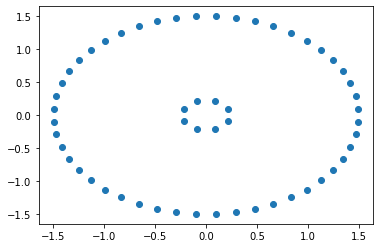

In [10]:
# Centroids by cell (ncells)
tri_centroids = tri_points.mean(axis=1, keepdims=False)

# Merge arrays of boundary cell-centers
n_circ_in_elts = circ_in_points.shape[0]
n_circ_out_elts = circ_out_points.shape[0]
bdry_points = np.concatenate([circ_in_points, circ_out_points], axis=0)
bdry_edge_centers = bdry_points.mean(axis=1, keepdims=False)
plt.scatter(bdry_edge_centers[:,0], bdry_edge_centers[:,1])


In [11]:
''' Compute boundary membership of cells '''
# IDs of nodes that lie on the circular boundary
node_id_circ_in = np.unique(circ_in_indices.ravel())
node_id_circ_out = np.unique(circ_out_indices.ravel())

# Compute boolean array showing which cell ID is on the boundaries
is_cell_on_bdry_circ_in = np.empty((tri_indices.shape[0]), dtype=bool)
is_cell_on_bdry_circ_out = np.empty((tri_indices.shape[0]), dtype=bool)
for i in range(tri_indices.shape[0]):
  # Check membership of any bdry node along axis 1
  if len(np.intersect1d(tri_indices[i,:], node_id_circ_in)) == 0:
    is_cell_on_bdry_circ_in[i] = False
  else:
    is_cell_on_bdry_circ_in[i] = True
  # Check membership of any bdry node along axis 1
  if len(np.intersect1d(tri_indices[i,:], node_id_circ_out)) == 0:
    is_cell_on_bdry_circ_out[i] = False
  else:
    is_cell_on_bdry_circ_out[i] = True

In [12]:
''' Compute tri-element areas '''
tri_areas = 0.5 * np.abs(np.cross(tri_points[:,2,:] - tri_points[:,0,:],
         tri_points[:,1,:] - tri_points[:,0,:])[:,-1])
tri_areas.sum(), np.pi*(1.5**2 - 0.25**2)

(6.871637684586148, 6.872233929727672)

Laplace fundamental solution

In [13]:
def G_vec(r):
  ''' Vectorized Laplace fundamental solution '''
  r2 = np.einsum("...i, ...i -> ...", r, r)
  np.log(r2, out=r2, where=r2>0)
  return r2 / (-4.0 * np.pi)

def G(r):
  ''' Laplace fundamental solution '''
  return -1 / (4.0 * np.pi) * np.log(np.einsum("...i, ...i -> ...", r, r))

def dGdn(r, nhat):
  ''' d/dn of Laplace fundamental solution '''
  rnorm = np.linalg.norm(r,axis=-1)
  drdn = np.einsum("...i, ...i -> ...", -nhat, r/rnorm)
  return -1 / (2.0 * np.pi * rnorm) * drdn

def rotate_vec(v):
  ''' Rotate vector counterclockwise 90 degrees along last axis '''
  w = v.copy()
  w[...,[1,0]] = w[...,[0,1]]
  w[...,0] *= -1
  return w

Area-integration of Laplace fundamental solution

In [43]:
def int_r_G(R):
  ''' r * G partially integrated in r from 0 to r = R '''
  return (-1 / (2.0 * np.pi)) * R * R * (2 * np.log(R) - 1.0) / 4.0

def integrateG_ws(x_vertices, N_per_side=3, debug=False, method=2):
  ''' Integrates G in triangle including weak singularity.
  Polar coordinate integration dr dtheta. Analytic integration in
  dr direction, numerical integration in theta(r).
  
  Due to curvature approximation of the dtheta element, max expected order is 2.
  '''
  theta_tot = 0
  I = 0
  # Compute vertex coordinates relative to centroid
  x_shift = x_vertices - x_vertices.mean(axis=0)
  for _ii in range(3):
    # Compute vector representing edge of triangle
    _dx = x_shift[_ii] - x_shift[_ii-1]
    for _jj in range(N_per_side):
      # Trap integration along this edge
      interval_start  = x_shift[_ii-1] + (_jj) * _dx / N_per_side
      interval_center = x_shift[_ii-1] + (_jj + 0.5) * _dx / N_per_side
      interval_end    = x_shift[_ii-1] + (_jj + 1) * _dx / N_per_side
      r_start  = np.linalg.norm(interval_start)
      r_center = np.linalg.norm(interval_center)
      r_end    = np.linalg.norm(interval_end)
      theta_start = np.arctan2(interval_start[1], interval_start[0])
      theta_end   = np.arctan2(interval_end[1], interval_end[0])
      dtheta = np.mod(theta_end - theta_start, 2*np.pi)
      if method==3:
        dI = (int_r_G(r_start) + 4 * int_r_G(r_center) + int_r_G(r_end)) * dtheta / 6.0
      elif method==2:
        dI = (0.5 * int_r_G(r_start) + 0.5 * int_r_G(r_end)) * dtheta
      else:
        raise ValueError("Input param `method` options: {2, 3}.")
      I += dI
      if debug:
        print(dtheta, dI)
        theta_tot += dtheta
        plt.plot(interval_center[0], interval_center[1], '.')

  if debug:
    plt.plot(0, 0, 'ko')
    print(f"Total angle: {theta_tot/np.pi} * pi")
  return I

In [47]:
# Node counting
n_cells = tri_centroids.shape[0]
n_bdry_node = bdry_edge_centers.shape[0]
N = n_cells + n_bdry_node

def assemble(plot_normal_vecs=False):
  K = np.zeros((N, n_bdry_node)) # Single-layer potential coefficient matrix (K @ du/dn)
  C = np.zeros((N, n_bdry_node)) # Double-layer potential coefficient matrix (dK/dn @ u)
  M = np.zeros((N, n_cells))       # Volume integral (dK/dt @ u)

  # Assemble global x points as list (bdry_centers, tri_centers)
  x_nodes = np.concatenate((bdry_edge_centers[:,0:2],
                            tri_centroids[:,0:2],), axis=0)

  # Matrix of all r-vectors with shape (n_bdry_nodes + n_cells, n_cells, 2)
  r_all = (x_nodes[:,np.newaxis,:] - bdry_edge_centers[np.newaxis,:,0:2])
  # Vectorized computation of G
  Gv = G_vec(r_all)

  # Compute boundary integrals
  for j in range(n_bdry_node):
    # Extract information about the boundary element
    edge = bdry_points[j,:,0:2]   # (2, ndim=2)
    x = bdry_edge_centers[j,0:2]  # (2,)

    # Compute dg (dgamma), dx = |dg|, dn
    dg = edge[1] - edge[0]        # (3,)
    dx = np.linalg.norm(dg)
    dn = rotate_vec(dg)           # (3,)
    dn /= np.linalg.norm(dn)

    for i, x_target in enumerate(x_nodes):
      # Compute distance vector
      r = x_target - x # (2,)
      if i == j: # Diagonal within boundary block
        # Singular part treatment: exact integration around pole
        r_eff = (dx/2)
        K[i,j] += 2 * (-1 / (2.0 * np.pi)) * (r_eff * np.log(r_eff) - r_eff)
      else:
        K[i,j] += Gv[i,j] * dx # @ dudn
        C[i,j] += dGdn(r, dn) * dx # @ u

    if plot_normal_vecs:
      plt.arrow(x[0], x[1], dn[0], dn[1], head_width=0.06)

  # Matrix of all r-vectors with shape (n_bdry_nodes + n_cells, n_cells, 2)
  r_all = (x_nodes[:,np.newaxis,:] - tri_centroids[np.newaxis,:,0:2])
  # Vectorized computation of G
  Gv = G_vec(r_all)

  # Compute domain integrals
  for j in range(n_cells):
    # Extract information about the boundary element
    x_center = tri_centroids[j,0:2]   # (2, ndim=2)
    x_vertices = tri_points[j,:,0:2]
    tri_area = tri_areas[j]

    for i, x_target in enumerate(x_nodes):
      # Compute distance vector
      r = x_target - x_center # (2,)
      if i == j + n_bdry_node: # Diagonal within volume block
        # Use second-order quadrature
        M[i,j] += integrateG_ws(x_vertices, N_per_side=10)
        # M[i,j] += (2 * np.pi) * (-1 / (2.0 * np.pi)) * r_eff * r_eff * (2 * np.log(r_eff) - 1.0) / 4.0
      else:
        # Add G(r) * dOmega_j
        M[i,j] += Gv[i,j] * tri_area # @ u
  return K, C, M

In [45]:
%load_ext line_profiler

The line_profiler extension is already loaded. To reload it, use:
  %reload_ext line_profiler


In [48]:
%lprun -f assemble assemble()

Timer unit: 1e-07 s

Total time: 2.15315 s
File: C:\Users\Fredric\AppData\Local\Temp\ipykernel_43888\2956311110.py
Function: assemble at line 6

Line #      Hits         Time  Per Hit   % Time  Line Contents
     6                                           def assemble(plot_normal_vecs=False):
     7         1        283.0    283.0      0.0    K = np.zeros((N, n_bdry_node)) # Single-layer potential coefficient matrix (K @ du/dn)
     8         1        169.0    169.0      0.0    C = np.zeros((N, n_bdry_node)) # Double-layer potential coefficient matrix (dK/dn @ u)
     9         1        211.0    211.0      0.0    M = np.zeros((N, n_cells))       # Volume integral (dK/dt @ u)
    10                                           
    11                                             # Assemble global x points as list (bdry_centers, tri_centers)
    12         2         50.0     25.0      0.0    x_nodes = np.concatenate((bdry_edge_centers[:,0:2],
    13         2          9.0      4.5      0.0 

# Theory

#### Theta-weighted timestepping
First, the integral representation theorem for nodes in the domain:

$$
\beta_\mathrm{d} \theta u^k + \beta_\mathrm{d}(1 - \theta) u^{k-1} = \int_\Gamma \left(
  K \frac{\partial u}{\partial n}
  - \frac{\partial K}{\partial n} u
  \right) d\gamma
  - \int_\Omega \left(
    \frac{u^{k} - u^{k-1}}{\Delta t}
    \right)
    K d\omega
$$

Rearranging dependent variables on the left and ``sources" on the right

$$
\beta_\mathrm{d} \theta u^k
+ \frac{1}{\Delta t} \int_\Omega u^{k} K d\omega 
- \int_\Gamma \left(
  K \frac{\partial u}{\partial n}
  \right) d\gamma
=
-\int_\Gamma \left(
\frac{\partial K}{\partial n} u
\right) d\gamma
+ \beta_\mathrm{d} (\theta - 1) u^{k-1}
+  \frac{1}{\Delta t} \int_\Omega u^{k-1} K d\omega
$$



or in term-by-term matrix form,

$$
\left(\beta_\mathrm{d} \theta I
+ \frac{1}{\Delta t}
M_\mathrm{dd} \right) u^{k}
-
K_{\mathrm{db}}
(\partial u / \partial n)_\Gamma^{k}
=
-C_\mathrm{db} u_\Gamma
+ \left(\beta_\mathrm{d} (\theta - 1) I
+ \frac{1}{\Delta t}
M_\mathrm{dd} \right) u^{k-1}
$$

Similarly, for the boundary points

$$
\frac{1}{\Delta t} \int_\Omega u^{k} K d\omega 
- \int_\Gamma \left(
  K \frac{\partial u}{\partial n}
  \right) d\gamma

\\ =
- \beta_\mathrm{b} \theta u_\Gamma^{k}
- \int_\Gamma \left(
\frac{\partial K}{\partial n} u
\right) d\gamma
+ \beta_\mathrm{b} (\theta - 1) u_\Gamma^{k-1}
+ \frac{1}{\Delta t} \int_\Omega u^{k-1} K d\omega
$$
where $u_\Gamma^{k}$ can be time-dependent. Consider for now $u_\Gamma$ being constant data. Then the matrix form is

$$
\frac{1}{\Delta t}
M_\mathrm{bd} u^{k}
-
K_{\mathrm{bb}}
(\partial u / \partial n)_\Gamma^{k}
=
\left( - C_\mathrm{bb} - \beta_\mathrm{b} I \right) u_\Gamma
+ \frac{1}{\Delta t}
M_\mathrm{bd} u^{k-1}
$$


Compactly,

$$
\begin{bmatrix}
-K_\mathrm{bb} & M_\mathrm{bd} / \Delta t \\
-K_\mathrm{db} & \beta_\mathrm{d} \theta I + M_\mathrm{dd} / \Delta t \\
\end{bmatrix}
\begin{bmatrix}
(\partial u/\partial n)_\Gamma^k \\
u^k \\
\end{bmatrix}
=
\begin{bmatrix}
-C_\mathrm{bb} - \beta_\mathrm{b} I \\
-C_\mathrm{db} \\
\end{bmatrix}
u_\Gamma
+
\begin{bmatrix}
M_\mathrm{bd} / \Delta t \\
\beta_\mathrm{d} (\theta - 1) I + M_\mathrm{dd} / \Delta t \\
\end{bmatrix} u^{k-1}
$$


### Annulus setup

Blue: approximation, red: numerical Bessel-sum root


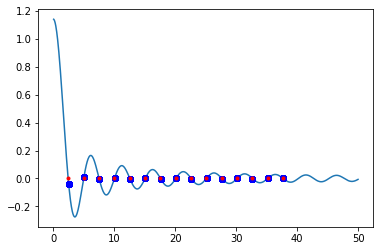

In [ ]:
''' Compute eigenfunctions in 2D annulus Dirichlet problem '''
# Determinant equation for system of coefficients to J0, Y0 in eigenfunction
j0, y0, j1, y1 = scipy.special.j0, scipy.special.y0, scipy.special.j1, scipy.special.y1

def det(m, a, b):
  ''' Determinant of matrix M in
    [0, 0]^T = M(m) @ [c_J, c_Y]^T,
  which is the eigenfunction condition for a Dirichlet problem in a 2D annulus.
  The general solution is a linear combination
    c_J * J0(r) + c_Y * Y0(r),
  and the linear system above admits non-trivial solutions when det M == 0.
  '''
  return j0(m*a) * y0(m*b) - j0(m*b) * y0(m*a)

def det_dm(m, a, b):
  ''' Derivative of function `det` with respect to argument m. '''
  return -(
    a * j1(m*a) * y0(m*b)
    + b * j0(m*a) * y1(m*b)
    - b * j1(m*b) * y0(m*a)
    - a * j0(m*b) * y1(m*a)
  )

N_roots = 15

# Approximate with cos(0.5 * m * (b-a)) and estimate roots of det with pi / (b-a)
m_guesses = np.arange(1,N_roots+1) * np.pi / (b - a)
roots = np.zeros_like(m_guesses)

for i, n in enumerate(m_guesses):
  roots[i] = scipy.optimize.fsolve(
    lambda m: det(m, a, b),
    m_guesses[i],
    fprime=lambda m: det_dm(m, a, b))

m_test_range = np.linspace(0,50,1001)[1:]
plt.plot(m_test_range, det(m_test_range, a, b))
# plt.plot(m_test_range, np.cos(m_test_range * (b-a) / 2 ))
for k in range(N_roots):
  plt.plot(m_guesses, det(m_guesses, a, b), 'ob')

plt.plot(roots, det(roots, a, b), '.r')
print("Blue: approximation, red: numerical Bessel-sum root")

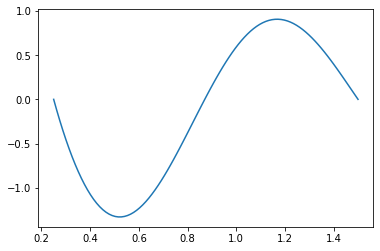

In [ ]:
''' Plot sample eigenfunction constructed using Bessels, setting C_j = 1.0 '''
_r = roots[1]
cj = 1.0
cy = - cj * j0 (_r * a) / y0(_r * a)

r_sample_range = np.linspace(a, b, 100)
summed_sample = cj * j0 (_r * r_sample_range) + cy * y0(_r * r_sample_range)
plt.plot(r_sample_range, summed_sample)

Text(0.5, 1.0, 'Analytic solution with 1-eigenfunction initial condition')

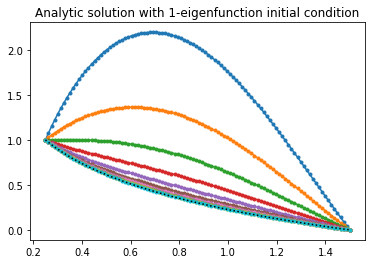

In [20]:
# Series solution for spherical shell heat conduction

def steady_term(r, t, a, b, dim=2):
  if dim == 2:
    return np.log(r / b) / np.log(a / b)
  elif dim == 3:
    return a / (a - b) * (1 - b / r)

def series_term(r, t, a, b, n, dim=2, alpha=1):
  if dim == 2:
    if n < 1 or n > roots.size:
      raise ValueError(f"n = {n} not valid. Need n = 1 to {roots.size} (or compute more roots).")
    eig = roots[n-1]
    # Compute coefficients using r = a boundary condition
    cj = 1.0
    cy = - cj * j0 (eig * a) / y0(eig * a)
    # Time-dependent factor, with diffusivity TODO: for other funtcions
    t_factor = np.exp(- alpha * eig * eig * t)
    # Space-dependent factor
    r_factor = cj * j0(eig * r) + cy * y0(eig * r)
    return t_factor * r_factor
  elif dim == 3: 
    # Array of eigenvalues
    eig = n * np.pi / (b - a)
    # Return eigenfunction term with nondimensionalizing scaling (b - a) / 2
    return (b - a) / 2 * np.exp(-eig*eig * t) * np.sin(eig*(r - a)) / r

def steady_ddr(r, t, a, b, dim=2):
  if dim == 2:
    return 1 / r / np.log(a / b)
  elif dim == 3:
    return  a * b / (a - b) / (r * r)

def series_ddr(r, t, a, b, n, dim=2, alpha=1.0):
  if dim == 2:
    if n < 1 or n > roots.size:
      raise ValueError(f"n = {n} not valid. Need n = 1 to {roots.size} (or compute more roots).")
    eig = roots[n-1]
    # Compute coefficients using r = a boundary condition
    cj = 1.0
    cy = - cj * j0 (eig * a) / y0(eig * a)
    # Time-dependent factor, with diffusivity TODO: for other funtcions
    t_factor = np.exp(- alpha * eig * eig * t)
    # Space-dependent factor
    r_factor = -eig * (cj * j1(eig * r) + cy * y1(eig * r))
    return t_factor * r_factor
  elif dim == 3:
    # Array of eigenvalues
    eig = n * np.pi / (b - a)
    # Return eigenfunction term with nondimensionalizing scaling (b - a) / 2
    return (b - a) / 2 * np.exp(-eig*eig * t) * (
        eig * np.cos(eig*(r - a)) / r
        - np.sin(eig*(r - a)) / (r*r)
      )

a = 0.25
b = 1.5
t_final = 1.0
for t in np.linspace(0, t_final, 10):
  r_test_range = np.linspace(a, b, 100)
  T_test = steady_term(r_test_range, t, a, b) + series_term(r_test_range, t, a, b, 1)
  plt.plot(r_test_range, T_test, '.-')

plt.plot(r_test_range, steady_term(r_test_range, t, a, b), 'k:')
plt.title("Analytic solution with 1-eigenfunction initial condition")

## Code

In [49]:
K, C, M = assemble()

LHS matrix and mappings from previous timestep are dense


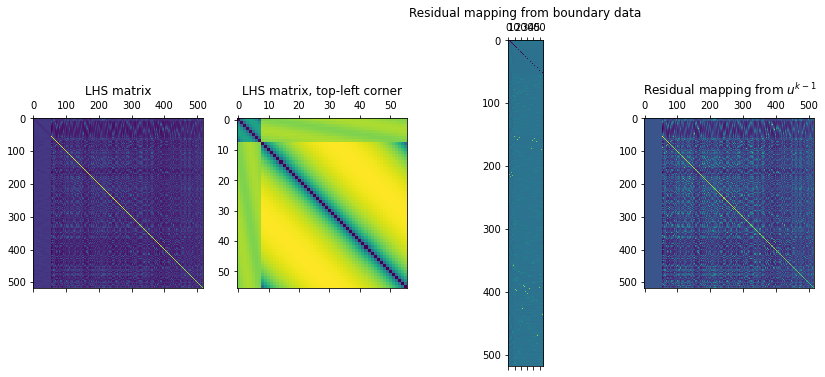

In [50]:
''' Matrix build '''

# Numerical method parameters
dt = 1e-2
theta = 1.0
# Geometric coefficient from deriving the boundary representation
beta_d = 1.0
beta_b = 0.5

L = np.concatenate((-K, M/dt), axis=1)
L[n_bdry_node:,n_bdry_node:] += beta_d * theta * np.eye(n_cells)

# Full-sized operators
C_op = -C.copy()
C_op[:n_bdry_node,:] -= beta_b * np.eye(n_bdry_node)
D_op = (M/dt).copy()
D_op[n_bdry_node:,:] += beta_d * (theta - 1.0) * np.eye(n_cells)
D_op = np.concatenate((np.zeros((N, n_bdry_node)), D_op), axis=1)

fig, ax = plt.subplots(1, 4, figsize=(14,6))
ax[0].matshow(L)
ax[0].set_title("LHS matrix")
ax[1].matshow(L[0:n_bdry_node, 0:n_bdry_node])
ax[1].set_title("LHS matrix, top-left corner")
ax[2].matshow(C_op)
ax[2].set_title("Residual mapping from boundary data")
ax[3].matshow(D_op)
ax[3].set_title("Residual mapping from $u^{k-1}$")

print("LHS matrix and mappings from previous timestep are dense")

In [51]:
L_11a = L[:n_circ_in_elts, :n_circ_in_elts]
L_11b = L[n_circ_in_elts:n_circ_out_elts, n_circ_in_elts:n_circ_out_elts]
L_22 = L[n_bdry_node:, n_bdry_node:]

print (f"Boundary 1 sub-block is symmetric: max abs diff {np.abs(L_11a - L_11a.T).max()}")
print (f"Boundary 2 sub-block is symmetric: max abs diff {np.abs(L_11b - L_11b.T).max()}")
print (f"Interior sub-block is asymmetric (different tri sizes): max abs diff {np.abs(L_22 - L_22.T).max()}")

Boundary 1 sub-block is symmetric: max abs diff 2.9785018201833324e-10
Boundary 2 sub-block is symmetric: max abs diff 2.9038137866477243e-10
Interior sub-block is asymmetric (different tri sizes): max abs diff 0.3411847611497095


In [52]:
# Set boundary conditions
u_bdry = np.zeros((n_bdry_node,1))
# Set Dirichlet data on the inner boundary (access using concatenation order)
u_bdry[0:node_id_circ_in.size] = 1.0

# Set initial conditions
r_eval = np.linalg.norm(tri_centroids, axis=1)
# Evaluate data in cell
IC_cell_data = steady_term(r_eval, 0.0, a, b) + series_term(r_eval, 0.0, a, b, 1)
# Evaluate Neumann data on boundary
IC_bdry_circ_in_data = -(
    steady_ddr(a, 0.0, a, b) + series_ddr(a, 0.0, a, b, 1)
  ) * np.ones((node_id_circ_in.shape))
IC_bdry_circ_out_data = (
    steady_ddr(b, 0.0, a, b) + series_ddr(b, 0.0, a, b, 1)
  ) * np.ones((node_id_circ_out.shape))

# Fill data into mixed vector
u0 = np.zeros((N, ))
u0[0:n_circ_in_elts] = IC_bdry_circ_in_data
u0[n_circ_in_elts:n_circ_in_elts+n_circ_out_elts] = IC_bdry_circ_out_data
u0[n_bdry_node:] = IC_cell_data
u0 = u0[:,np.newaxis]

In [ ]:
''' Timestepping '''

u = u0.copy()
lu, piv = scipy.linalg.lu_factor(L)

# Timestepping
N_t = 100

# v_hist = np.zeros((N_t, n_circ_elts,))
u_hist = np.zeros((N_t, *u0.shape,))

for i in range(N_t):
  # Solve equation
  #   L @ q^{k} == CG @ u_Gamma + DG @ q^{k-1}
  # u = np.linalg.solve(L, C_op @ u_bdry + D_op @ u)
  u = scipy.linalg.lu_solve((lu, piv), C_op @ u_bdry + D_op @ u)
  # v_hist[i,:] = u[:n_circ_elts].ravel()
  u_hist[i,...] = u
# plt.plot(u)

1.1357155389029931

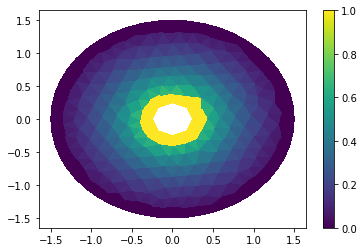

In [54]:
# Extract du/dn, u_interior (u_Omega)
v = u[:n_bdry_node]
u_int = u[n_bdry_node:]

u_show = u_int.copy()
u_show[np.where(is_cell_on_bdry_circ_in)] = 1.0
u_show[np.where(is_cell_on_bdry_circ_out)] = 0.0

triangulation = matplotlib.tri.Triangulation(mesh.points[:,0], mesh.points[:,1], tri_indices)
plt.tripcolor(triangulation, u_show.squeeze())
plt.colorbar()
u_int.max()

In [55]:
''' Plot along a line probe '''
trifinder = triangulation.get_trifinder()

probe_line = np.linspace(0.25+.01, 1.5-.01, 50)
pick_indices = [int(trifinder(x, 0.0)) for x in probe_line]
u_along_line = u_int[pick_indices]

u_int_hist = u_hist[:,n_bdry_node:,0]
u_hist_along_line = u_int_hist[:,pick_indices]

Text(0.5, 1.0, 'Initial condition')

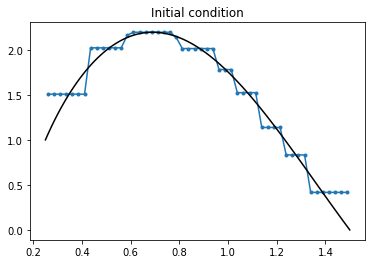

In [56]:
u0_int = u0[n_bdry_node:]
plt.plot(probe_line, u0_int[pick_indices], '.-')
plt.plot(r_test_range, steady_term(r_test_range, 0, a, b) + series_term(r_test_range, 0, a, b, 1), 'k-')
plt.title("Initial condition")

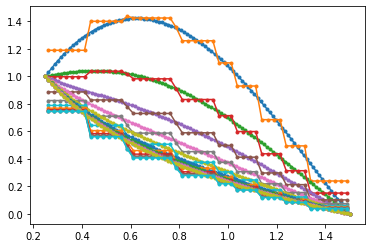

In [58]:
t_plot_vec = 10*(dt + dt*np.arange(0,10))

for i, t in enumerate(t_plot_vec):
  # Compute constructed analytic solution
  r_test_range = np.linspace(a, b, 100)
  T_test = steady_term(r_test_range, t, a, b) + series_term(r_test_range, t, a, b, 1)
  # Plot analytic
  plt.plot(r_test_range, T_test, '.-')
  # Plot numerical
  plt.plot(probe_line, u_hist_along_line[10*i+9,:], '.-')

# plt.plot(r_test_range, steady_term(r_test_range, t, a, b), 'k:')

Text(0, 0.5, '$\\partial u/\\partial r$')

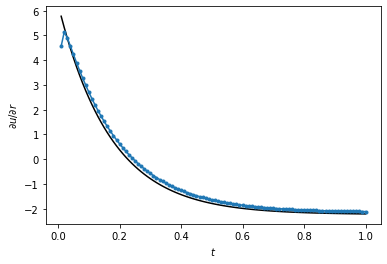

In [59]:
''' Compare normal gradient value at boundary '''

# Extract gradients at inner circle boundary
dudr_hist = u_hist[:,:n_circ_in_elts,0]
# dudr_numerical_steady = -u_s[:n_circ_in_elts].squeeze()

t_plot_range = (dt + dt*np.arange(0,N_t))
dudr_exact = steady_ddr(a, 0.0, a, b, dim=2) + series_ddr(a, t_plot_range, a, b, 1, dim=2, alpha=1.0)
plt.plot(t_plot_range, dudr_exact, 'k-')
plt.plot(t_plot_range, -dudr_hist.mean(axis=1), '.-')
plt.xlabel("$t$")
plt.ylabel("$\partial u/\partial r$")